In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import transforms
from tqdm import tqdm

from src.diffeomorphisms.vector.r2.river import RiverVectorDiffeomorphism
from src.diffeomorphisms.vector.transform import TransformVectorDiffeomorphism
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.k_fold.pullback.standard import StandardPullbackKfoldVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.standard.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.parity.tanh import TanhParityTransform
from src.transforms.householder_linear import HouseholderLinearTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# set font size for plots
plt.rcParams.update({'font.size': 20})

# manual seed
torch.manual_seed(31)

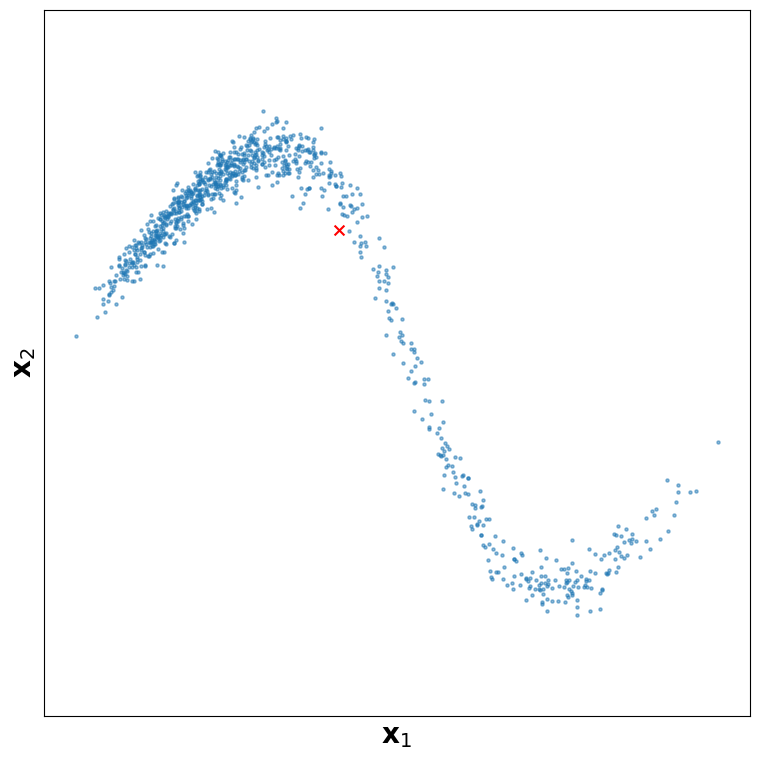

In [2]:
# generate data
n_samples_train = 1000
n_samples_test = 100
n_samples = n_samples_train + n_samples_test

def generate_river_data(n_samples):
    latent_data = torch.randn(n_samples, 2) * torch.tensor([0.1, 5.0]) + torch.tensor([0.0, 4.0])
    data = RiverVectorDiffeomorphism(1,1).inverse(latent_data)
    # multiply data with random rotation matrix
    theta = torch.rand(1) * torch.pi
    rotation_matrix = torch.tensor([[torch.cos(theta), -torch.sin(theta)],
                                    [torch.sin(theta), torch.cos(theta)]])
    data = data @ rotation_matrix.T
    return data

data = generate_river_data(n_samples)
# normalize data
data = (data - data.mean(dim=0)) / data.std(dim=0)
data_train = data[:n_samples_train]
data_test = data[n_samples_train:]

data_loader = DataLoader(data_train, batch_size=128, shuffle=True)

# plot data
plt.figure(figsize=(8,8))
plt.scatter(0.3,0.3, s=50, c='red', marker='x')  # plot origin
plt.scatter(data_train[:,0], data_train[:,1], s=5, alpha=0.5)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.tight_layout()
plt.axis('equal')
plt.show()

In [3]:
# define the learnable diffeomorphism model
def create_flow_model(dim, n_flows, n_hoho, order):
    transforms_list = []
    for i in range(n_flows):
        # transforms_list.append(transforms.normalization.ActNorm(features=dim)) # not sure why this gives issues
        for k in range(n_hoho):
            transforms_list.append(HouseholderLinearTransform(dim))
        transforms_list.append(TanhParityTransform(dim, order, parity=i%2))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return TransformVectorDiffeomorphism(dim, flow_transforms)

def construct_krae_model(dim, n_flows, n_hoho, order, latent_dim, k_folds):
    # construct diffeomorphism model
    phi = create_flow_model(dim, n_flows, n_hoho, order).to(device)
    # construct krae model
    # base_point = nn.Parameter(torch.randn(dim).to(device))
    base_point = torch.tensor([0.3,0.3]).to(device)
    # tangent_basis = nn.Parameter(torch.randn(latent_dim, dim).to(device))
    tangent_basis = torch.tensor([[1.0,-2.0]]).to(device)
    # model = StandardPullbackKfoldVectorRiemannianAutoencoder(phi, base_point, tangent_basis, K=k_folds, ONB=False).to(device)
    model = StandardPullbackVectorRiemannianAutoencoder(phi, base_point, tangent_basis, ONB=False).to(device)
    return model

In [ ]:
# initialize the model
dim = 2
n_flows = 4
n_hoho = 2
order = 2

latent_dim = 1
k_folds = 10

model = construct_krae_model(dim, n_flows, n_hoho, order, latent_dim, k_folds)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
# # debug model
# x = data_train[0:5].to(device)
# recon_x = model(x)
# print("Input x shape:", x.shape)
# print("Reconstructed x shape:", recon_x.shape)  
# print(recon_x)

# # debug manifold
# manifold = model.manifold
# geodesic = manifold.geodesic(x[0][None,None], x[1][None,None], torch.linspace(0,1,10).to(device))
# print(geodesic.shape)
# print(geodesic)

# # debug phi
# phi = manifold.phi
# z = phi(x)
# print("Phi x shape:", z.shape)
# print(z)

# print(x)

# # deubg individual transforms
# for i, transform in enumerate(phi.transform._transforms):
#     print(f"Transform {i}:")
#     x,_ = transform.forward(x)
#     print(x)    

 12%|█▏        | 24/200 [00:02<00:18,  9.68it/s]

Epoch [25/200], Loss: 0.2692
Test Loss: 0.2778


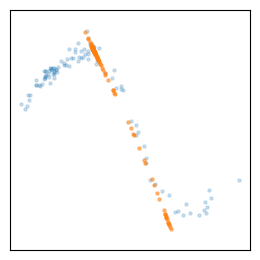

 24%|██▍       | 49/200 [00:05<00:15, 10.05it/s]

Epoch [50/200], Loss: 0.2772
Test Loss: 0.2914


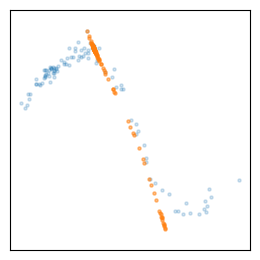

 37%|███▋      | 74/200 [00:07<00:13,  9.69it/s]

Epoch [75/200], Loss: 0.2597
Test Loss: 0.2673


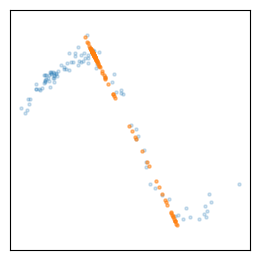

 50%|████▉     | 99/200 [00:10<00:10,  9.66it/s]

Epoch [100/200], Loss: 0.2765
Test Loss: 0.2755


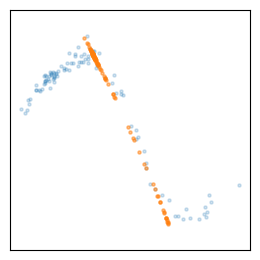

 62%|██████▏   | 124/200 [00:12<00:08,  9.43it/s]

Epoch [125/200], Loss: 0.3287
Test Loss: 0.3374


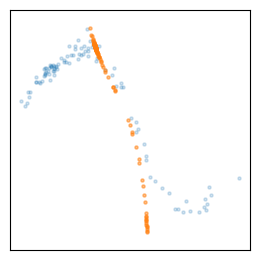

 74%|███████▍  | 149/200 [00:15<00:05,  9.93it/s]

Epoch [150/200], Loss: 0.4750
Test Loss: 0.5069


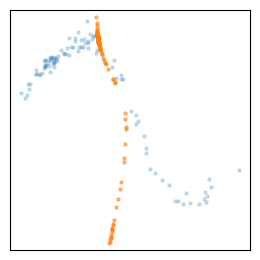

 86%|████████▋ | 173/200 [00:17<00:02,  9.87it/s]

Epoch [175/200], Loss: 0.3004
Test Loss: 0.3078


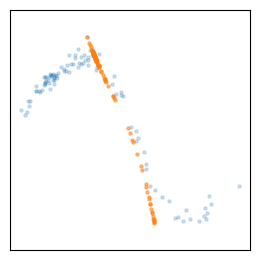

100%|█████████▉| 199/200 [00:20<00:00,  9.54it/s]

Epoch [200/200], Loss: 0.3656
Test Loss: 0.3880


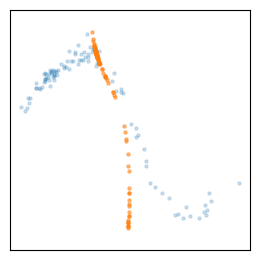

100%|██████████| 200/200 [00:20<00:00,  9.63it/s]


In [6]:
# training loop
n_epochs = 200

for epoch in tqdm(range(n_epochs)):
    model.train()
    total_loss = 0.0
    for batch_data in data_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()
        recon_data = model(batch_data)
        loss = F.mse_loss(recon_data, batch_data)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_data.size(0)
    total_loss /= len(data_loader.dataset)
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {total_loss:.4f}')
        with torch.no_grad():
            data_test = data_test.to(device)
            recon_test = model(data_test)
            test_loss = F.mse_loss(recon_test, data_test)
            print(f'Test Loss: {test_loss.item():.4f}')

        # plot some reconstructions
        plt.figure(figsize=(3,3))
        plt.scatter(data_test[:,0], data_test[:,1], s=5, alpha=0.2)
        plt.scatter(recon_test[:,0], recon_test[:,1], s=5, alpha=0.5)
        plt.xticks([])  # Remove x-axis ticks
        plt.yticks([])  # Remove y-axis ticks
        plt.tight_layout()
        plt.axis('equal')
        plt.show()

Test Loss: 0.3880


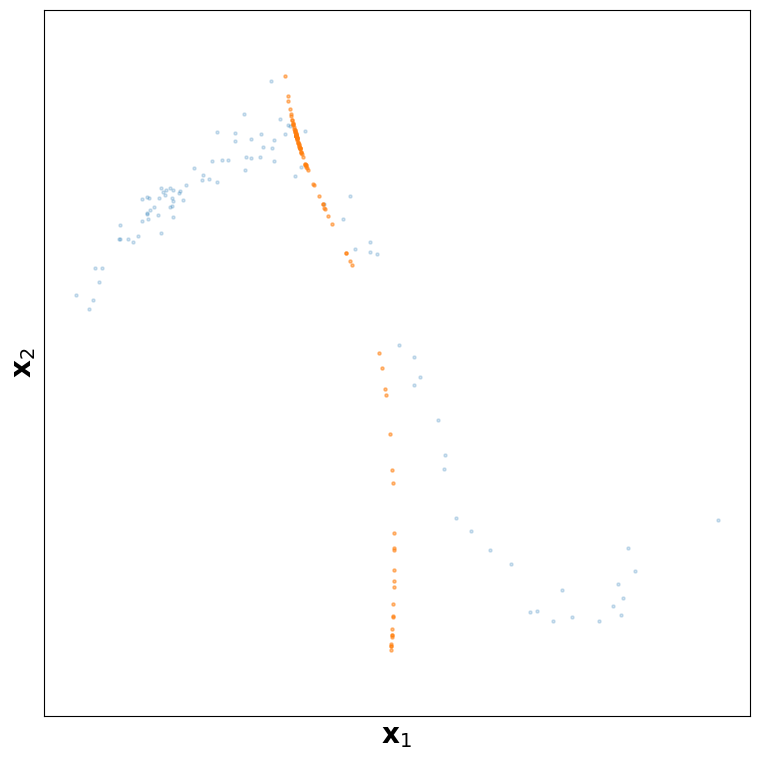

In [7]:
# evaluate on test data
model.eval()
with torch.no_grad():
    data_test = data_test.to(device)
    recon_test = model(data_test)
    test_loss = F.mse_loss(recon_test, data_test)
    print(f'Test Loss: {test_loss.item():.4f}')

# plot some reconstructions
plt.figure(figsize=(8,8))
plt.scatter(data_test[:,0], data_test[:,1], s=5, alpha=0.2)
plt.scatter(recon_test[:,0], recon_test[:,1], s=5, alpha=0.5)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.tight_layout()
plt.axis('equal')
plt.show()